***
# Mapping Wildfires
#### by Paul Ghisletti, as part of the SDS210 course (spring semester '26)

***

In [212]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import requests
from datetime import datetime

***
## API-Setup
Make sure you followed the steps 2.1. to 2.3. in the `README.md` file on how to set your individual API-key: Check, whether the following output matches your individual API-key from FIRMS. Here, you can also see how many free transactions you have left with your api-key

In [213]:
load_dotenv()

api_key = os.getenv("MY_API_KEY")
print(f"API-Key: {api_key}")

url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + api_key
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  print ("There is an issue with your API key. Please check the value of MY_API_KEY in your .env file and try again.")

API-Key: 3d1ef73c3c932e5f3738d87f205a9cec


transaction_limit             5000
current_transactions           462
transaction_interval    10 minutes
dtype: object

We can also define a function which tells us how many transactions we have used so far. This can be used to check, how many transactions one API query costs (code from the [FIRMS notebook on *API use*](https://firms.modaps.eosdis.nasa.gov/academy/data_api/)):

In [214]:
def get_transaction_count() :
  count = 0
  try:
    response = requests.get(url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print (f'Our current transaction count is {tcount}')

Our current transaction count is 462


***
## 1. Loading a dataset through the API
### 1.1. Check availability
Because the latency differs between the sensors, we first need to check the date availability. We can later use this information when automating the download.

In [215]:
def get_availability_all(api_key):
    url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + api_key + '/ALL'
    return pd.read_csv(url) 

availability_all_df = get_availability_all(api_key)
display(availability_all_df.head(10))

,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-10
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-05-10
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-10
5,VIIRS_SNPP_NRT,2026-03-01,2026-05-10
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-05-09
8,GOES_NRT,2022-08-09,2026-05-10
9,BA_MODIS,2000-11-01,2026-02-01


### 1.2. Download data
In this chapter, we will define a function which will automatically get the API data. All the user has to do is provide the following parameters:
- The desired sensor
- The area which the data should cover
- The date of data acquisition
- Time frame of the data  

Since this is a function where we need to check numerous parameter inputs, it is helpful to define helper functions to make the final function more readable. These helpers mainly check for correct input format and type.  

Because we enable the user to simply type the continent or country for the desired extent, we need a dataset that stores the bounding box coordinates which we can reference the user input against. This is done by importing a `.gpkg` file with all 198 countries of the world (193 UN members, 2 UN observer states, 3 disputed states).  
First, we import the `.gpkg` file as a `GeoDataFrame`, which we created from `ne_10m_admin_0_countries.shp` in the dedicated Jupyter Notebook.

In [216]:
countries_gdf = gpd.read_file("../data/raw/198_countries.gpkg").to_crs(epsg=4326)

This chunk of code defines all the helper functions needed for the main function and the main function itself:

In [217]:
# Helper Functions for checking parameter inputs:
# -----------------------------------------------
def check_sensor(sensor):
    valid_sensors = set(availability_all_df["data_id"]) 
    if sensor not in valid_sensors:
        raise ValueError("Sensor: Invalid sensor name.")

def check_area_list(area):
    west, south, east, north = area
    lat_min = -90
    lat_max = 90
    lon_min = -180
    lon_max = 180
    # check invalid longitude values
    if west < -180 or west > 180: 
        raise ValueError("Area: Invalid coordinate: west")
    if east < -180 or east > 180: 
        raise ValueError("Area: Invalid coordinate: east")
    # check invalid latitude values
    if south < -90 or south > 90:
        raise ValueError("Area: Invalid coordinate: south")
    if north < -90 or north > 90:
        raise ValueError("Area: Invalid coordinate: north")
    # check order of list
    if west > east:
        raise ValueError("Area: Invalid coordinate: west is larger than east")
    if south > north:
        raise ValueError("Area: Invalid coordinate: south is larger than north")
    
def check_date_str(date, sensor, max_date_time):
    is_none = date is None
    is_str = type(date) == str
    if not is_none and not is_str:
        raise ValueError("Date: Invalid input type. Either str or None")
    
    if is_str:
        try:
            date_time = datetime.strptime(date, "%Y-%m-%d")
        except ValueError:
            raise ValueError("Date: Must be in YYYY-MM-DD format and be a valid calendar date")
        if date_time > max_date_time:
            raise ValueError(f"Date: Desired date not available for {sensor}")
        
def check_n_days(n_days):
    if not type(n_days) == int:
        raise ValueError("N_days: Type must be int.")
    if n_days < 1 or n_days > 5:
        raise ValueError("N_days: Minimum 1 day, maximum 5 days.")

# Helper Functions for calculating area based on country or continent:
# --------------------------------------------------------------------
countries_gdf = gpd.read_file("../data/raw/geoBoundariesCGAZ_ADM0.gpkg").to_crs(epsg=4326)
countries_gdf = countries_gdf[countries_gdf['shapeType'] == "ADM0"]

def get_area_coord(area: str) -> str:
    # dictionary with bounding boxes for continents
    continents = {
        "North America": [-170, 5, -50, 83],
        "South America": [-82, -56, -35, 13],
        "Europe": [-25, 34, 45, 72],
        "Asia": [25, -10, 180, 80],
        "Africa": [-20, -35, 55, 38],
        "Oceania": [110, -50, 180, 0],
        "Australia": [110, -50, 180, 0]
    }
    
    # check validity of area input
    is_continent = area in continents
    is_country = (area in countries_gdf["shapeName"].values
                  or area in countries_gdf["shapeGroup"].values)
    if not is_continent and not is_country:
        raise ValueError("Area: Invalid country code, country name or continent.")
    
    if is_continent:
        bbox = continents[area]

    else:
        country_gdf = countries_gdf[
            (countries_gdf["shapeName"] == area) |
            (countries_gdf["shapeGroup"] == area)
        ]
        minx, miny, maxx, maxy = country_gdf.geometry.total_bounds # gets coordinates of bounding box
        bbox = [minx, miny, maxx, maxy]

    return ",".join(map(str, bbox))

# API Function
# ------------
def area_api_query(sensor: str, area: list|str = 'world', date: str | None = None, n_days: int = 1) -> pd.DataFrame:
    """
    Query the NASA FIRMS API for area data for a given sensor and date. If date is not provided, it will return the most recent data.

    Choose one of these sensors:
        'LANDSAT_NRT',
        'MODIS_NRT',
        'MODIS_SP',
        'VIIRS_NOAA20_NRT',
        'VIIRS_NOAA20_SP',
        'VIIRS_NOAA21_NRT',
        'VIIRS_SNPP_NRT',
        'VIIRS_SNPP_SP'

    Parameters:
    -----------
    sensor : str
        Must be from the sensors list.

    area : list or str, optional
        The area for which to query data, 4 options:
        - 'world' for global coverage
        - Country name or ISO 3166-1 alpha-3 country codes (e.g. "Algeria" or "DZA")
        - Continent name (e.g. "North America")
        - Coordinate bounding box with format [west,south,east,north] (e.g. [-180,-90,180,90])

    date : str, optional
        Date in the format 'YYYY-MM-DD'. If not provided, the most recent data will be returned.

    n_days: int, optional
        Number of days that the data should cover.
        Max = 5
        Default value = 1

    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the area data for the specified sensor and date.
    """
    # sensor
    # ------
    if check_sensor(sensor) == False:
        raise ValueError("Sensor: Invalid sensor name, check list of available sensors.")
    print(f"Sensor input:{sensor}")
    
    # area
    # ----
    if type(area) == str:
        if area == 'world':
            area_str = area
        else:
            area_str = get_area_coord(area)
    elif type(area) == list:
        check_area_list(area)
        area_str = ",".join(map(str, area)) # converts input list to str for url use
    else:
        raise ValueError("Area: Anvalid input type. Must be either str or list")
    print(f"Area input: {area_str}")

    # date
    # ----
    availability_all_df = get_availability_all(api_key)
    max_date = availability_all_df.loc[
            availability_all_df["data_id"] == sensor,
            "max_date"
        ].iloc[0]
    max_date_time = datetime.strptime(max_date, "%Y-%m-%d")

    check_date_str(date, sensor, max_date_time)

    if date is None:
        date_str = max_date_time.strftime("%Y-%m-%d")
    if type(date) == str:
        date_str = date
    print(f"Date input: {date_str}")

    # n_days
    # ------
    check_n_days(n_days)
    n_days = str(n_days)
    print(f"N_days input: {n_days}")
    print("All input correct")

    # API query
    # ---------
    area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + api_key + '/' + sensor + '/' + area_str + '/' + n_days + '/' + date_str
    print(f"URL: {area_url}")
    output_df = pd.read_csv(area_url)
    
    return output_df

Let us check, whether this monstrosity of a function actually works:

In [218]:
df_wf = area_api_query('VIIRS_NOAA20_NRT', n_days=5)
display(df_wf.head(1))

Sensor input:VIIRS_NOAA20_NRT
Area input: world
Date input: 2026-05-10
N_days input: 5
All input correct
URL: https://firms.modaps.eosdis.nasa.gov/api/area/csv/3d1ef73c3c932e5f3738d87f205a9cec/VIIRS_NOAA20_NRT/world/5/2026-05-10


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,55.54527,44.22956,298.35,0.5,0.66,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.59,0.58,N


We can see that there is a longitude and latitude column in the csv file which we imported as a `pd.DataFrame`. We can use these two columns to convert it to a `gpd.GeoDataFrame`, which contains geospatial information (point geometries in this case):

In [219]:
# now convert latitude, longitude values into point geometry

gdf_wf = gpd.GeoDataFrame(
    df_wf, geometry=gpd.points_from_xy(df_wf.longitude, df_wf.latitude), crs="EPSG:4326"
)

# show top 3 records
gdf_wf.tail(10)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
16123,19.40642,-155.26579,296.79,0.52,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,284.77,3.75,N,POINT (-155.26579 19.40642)
16124,19.40747,-155.27040,324.43,0.51,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,299.69,3.75,N,POINT (-155.2704 19.40747)
16125,19.40855,-155.27515,321.78,0.51,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,294.79,4.73,N,POINT (-155.27515 19.40855)
16126,19.40965,-155.27998,311.23,0.51,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,290.77,4.73,N,POINT (-155.27998 19.40965)
16127,19.41079,-155.28502,302.73,0.51,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,288.16,1.81,N,POINT (-155.28502 19.41079)
16128,19.41200,-155.29033,303.92,0.51,0.66,2026-05-10,1249,N20,VIIRS,n,2.0NRT,287.14,1.81,N,POINT (-155.29033 19.412)
16129,-37.76336,175.41528,295.41,0.44,0.38,2026-05-10,1304,N20,VIIRS,n,2.0NRT,281.82,1.06,N,POINT (175.41528 -37.76336)
16130,-37.76161,175.41394,297.41,0.44,0.38,2026-05-10,1304,N20,VIIRS,n,2.0NRT,283.61,0.83,N,POINT (175.41394 -37.76161)
16131,-35.28567,173.96185,306.42,0.55,0.43,2026-05-10,1304,N20,VIIRS,n,2.0NRT,284.58,1.56,N,POINT (173.96185 -35.28567)
16132,-35.28448,173.96152,309.25,0.55,0.43,2026-05-10,1304,N20,VIIRS,n,2.0NRT,284.28,1.50,N,POINT (173.96152 -35.28448)


Having transformed our data frame to a geospatial data frame, we can now use geopandas built-in `.plot()` method to plot all wildfires from the most recent day available worldwide:

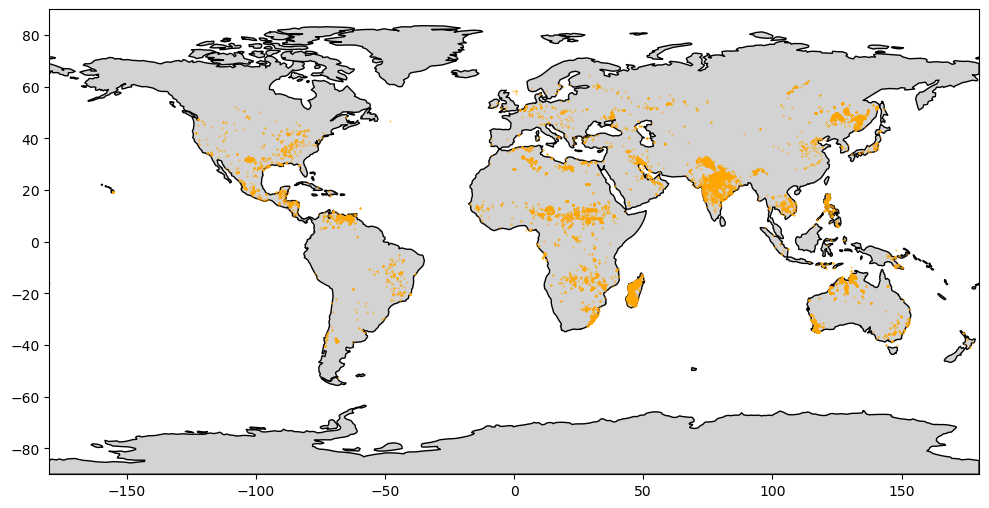

In [220]:
# We first need to import a file with global boundary geometries
path = "../data/raw/ne_110m_land/ne_110m_land.shp"
world = gpd.read_file(path).to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12,7))

world.plot(ax=ax,
           color="lightgrey",
           edgecolor="black")

gdf_wf.plot(ax=ax,
         color="orange",
         markersize=0.1
         )
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_aspect("equal")

plt.show()

## 2. Cleaning the dataframe
Before trying to visualise all the interesting data contained in the dataset, we must clean it first and prepare it for future steps. We can get an overview of the dataset by looking at the columns and what type of data they contain.



In [221]:
def overview(df, name="dataset"):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True)
    }).sort_values(["dtype", "n_unique"], ascending=[True, False])

    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    return summary

overview(gdf_wf)


=== dataset ===
Shape: (16133, 15)


,dtype,n_unique
latitude,float64,16095
longitude,float64,16079
bright_ti4,float64,4347
bright_ti5,float64,4310
frp,float64,2205
scan,float64,49
track,float64,43
geometry,geometry,16133
acq_time,int64,130
confidence,str,3


Based on these insights, we can now decide how to clean and change the variables and entries:
- change the acquisition date and acquisition time to a valid datetime format.  

It seems like the API delivers an already clean data set which is why no more steps are needed.
### 2.1. Converting to datetime
At the moment, the time and date are stored in separate columns as `str`. The following step will convert it into a single column containing gpd.datetime objects. Afterwards, we can drop the now useless `acq_time` and `acq_date` columns.

In [ ]:
gdf_wf["datetime"] = pd.to_datetime(
    gdf_wf["acq_date"] + " " + gdf_wf["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True
)
gdf_wf_clean = gdf_wf.drop(columns=["acq_time", "acq_date"])

,latitude,longitude,bright_ti4,scan,track,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry,datetime
0,55.54527,44.22956,298.35,0.50,0.66,N20,VIIRS,n,2.0NRT,273.59,0.58,N,POINT (44.22956 55.54527),2026-05-10 00:45:00+00:00
1,56.10518,41.52589,300.58,0.39,0.59,N20,VIIRS,n,2.0NRT,273.38,0.37,N,POINT (41.52589 56.10518),2026-05-10 00:45:00+00:00
2,56.13894,44.11552,304.68,0.47,0.64,N20,VIIRS,n,2.0NRT,273.54,1.16,N,POINT (44.11552 56.13894),2026-05-10 00:45:00+00:00
3,56.14229,44.12248,298.69,0.47,0.64,N20,VIIRS,n,2.0NRT,273.87,0.81,N,POINT (44.12248 56.14229),2026-05-10 00:45:00+00:00
4,59.50502,32.09431,316.92,0.47,0.40,N20,VIIRS,n,2.0NRT,271.38,2.11,N,POINT (32.09431 59.50502),2026-05-10 00:45:00+00:00
